In [9]:
%cd /Users/masha/Documents/GSOC/GSoC-Quantum-Diffusion-Model

from utils.post_training import *
from utils.statistics import *
from utils.plotting import *
from utils.encodings import *
from utils.haar_noising_script import apply_haar_scrambling

import numpy as np
import h5py
import time

import torch
import torch.nn as nn
import torch.optim as optim

import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import scipy.linalg

import pennylane as qml

/Users/masha/Documents/GSOC/GSoC-Quantum-Diffusion-Model


In [13]:
QG_channel = 1
filename = f"data/QG{QG_channel}_64x64_1k"
# filename = f"data/QG{QG_channel}_16x16_1k"
with h5py.File(filename, "r") as f:
    data_X = np.array(f["X"])

# If the dataset includes channels, select the requested QG channel (1-indexed)
if data_X.ndim == 4:
    data_X = data_X[..., QG_channel - 1]

# Preprocess like other notebooks: log, normalize, map to [-1, 1]
data_X = data_X.astype(np.float32)
data_X = np.log1p(data_X)
data_X = data_X / data_X.max()
data_X = 2.0 * data_X - 1.0

print("Dataset shape:", data_X.shape, "min:", data_X.min(), "max:", data_X.max())


Dataset shape: (1000, 64, 64) min: -1.0 max: 1.0


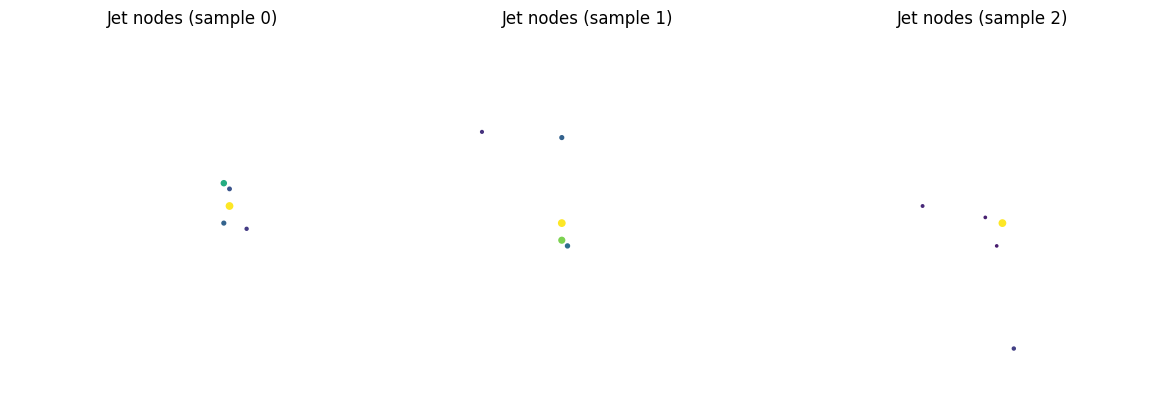

In [ ]:
# --- Visualize jet-structure learning target (energy-based nodes only) ---

def _to_single_channel(sample, channel=0):
    if sample.ndim == 3:
        return sample[..., channel]
    return sample

def _normalize_for_graph(img):
    img = img.astype(np.float32)
    if img.min() < 0:
        img = (img - img.min()) / (img.max() - img.min() + 1e-12)
    elif img.max() > 1.0:
        img = img / (img.max() + 1e-12)
    return img

def extract_energy_nodes(img, energy_quantile=0.995):
    """
    Keep the minimal set of highest-intensity pixels whose cumulative
    energy reaches the given quantile. Each pixel is its own node.
    """
    img_n = _normalize_for_graph(img)
    flat = img_n.flatten()
    total = flat.sum()

    if total <= 0:
        return img_n, np.empty((0, 2)), np.array([])

    order = np.argsort(flat)[::-1]  # descending by intensity
    cumsum = np.cumsum(flat[order])
    cutoff_idx = np.searchsorted(cumsum, energy_quantile * total)
    keep_idx = order[:cutoff_idx + 1]

    coords = np.column_stack(np.unravel_index(keep_idx, img_n.shape))
    intens = flat[keep_idx]

    return img_n, coords, intens

def plot_energy_nodes(ax, img, energy_quantile=0.995, cmap="viridis"):
    img_n, coords, intens = extract_energy_nodes(img, energy_quantile=energy_quantile)
    H, W = img_n.shape

    ax.set_xlim(-0.5, W - 0.5)
    ax.set_ylim(H - 0.5, -0.5)
    ax.set_aspect("equal")
    ax.axis("off")

    if intens.size == 0:
        return 0

    sizes = 20.0 * (intens / (intens.max() + 1e-12) + 0.05)
    ax.scatter(coords[:, 1], coords[:, 0], s=sizes, c=intens, cmap=cmap, vmin=0, vmax=intens.max())
    return len(intens)

num_samples_to_plot = 3
sample_indices = list(range(num_samples_to_plot))

fig, axes = plt.subplots(1, num_samples_to_plot, figsize=(4 * num_samples_to_plot, 4))
if num_samples_to_plot == 1:
    axes = [axes]

for i, idx in enumerate(sample_indices):
    sample = _to_single_channel(data_X[idx], channel=0)
    n_nodes = plot_energy_nodes(axes[i], sample, energy_quantile=0.995)
    axes[i].set_title(f"Jet nodes (sample {idx})\n#nodes={n_nodes}")

plt.tight_layout()
plt.show()


In [30]:
# --- (1) Fixed-length node set with mask (energy-based foreground only) ---
energy_quantile = 0.995
K_max = 128
num_samples_for_nodes = min(1000, data_X.shape[0])

def nodes_to_fixed(coords, intens, H, W, K_max):
    """Convert variable-length nodes to fixed-length (K_max, 3) with mask."""
    if intens.size == 0:
        return np.zeros((K_max, 3), dtype=np.float32), np.zeros((K_max,), dtype=np.float32), 0

    order = np.argsort(intens)[::-1]
    coords = coords[order]
    intens = intens[order]

    # Normalize coordinates to [-1, 1]
    xs = coords[:, 1] / (W - 1 + 1e-12)
    ys = coords[:, 0] / (H - 1 + 1e-12)
    xs = 2.0 * xs - 1.0
    ys = 2.0 * ys - 1.0

    feats = np.stack([xs, ys, intens], axis=1).astype(np.float32)
    n = min(len(feats), K_max)

    out = np.zeros((K_max, 3), dtype=np.float32)
    mask = np.zeros((K_max,), dtype=np.float32)
    out[:n] = feats[:n]
    mask[:n] = 1.0
    return out, mask, n

nodes_all = np.zeros((num_samples_for_nodes, K_max, 3), dtype=np.float32)
mask_all = np.zeros((num_samples_for_nodes, K_max), dtype=np.float32)
lengths = np.zeros((num_samples_for_nodes,), dtype=np.int32)

for i in range(num_samples_for_nodes):
    sample = _to_single_channel(data_X[i], channel=0)
    img_n, coords, intens = extract_energy_nodes(sample, energy_quantile=energy_quantile)
    H, W = img_n.shape
    nodes, mask, n = nodes_to_fixed(coords, intens, H, W, K_max)
    nodes_all[i] = nodes
    mask_all[i] = mask
    lengths[i] = n

print("Nodes tensor:", nodes_all.shape, "Mask tensor:", mask_all.shape)
print("Avg #nodes:", lengths.mean(), "Max #nodes:", lengths.max())

# torch tensors for modeling
nodes_t = torch.tensor(nodes_all, dtype=torch.float32)
mask_t = torch.tensor(mask_all, dtype=torch.float32)

Nodes tensor: (1000, 128, 3) Mask tensor: (1000, 128)
Avg #nodes: 22.761 Max #nodes: 59


In [32]:
# --- (2) Foreground-only flow matching model (masked) ---
device = "mps" if torch.mps.is_available() else ("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# Flatten nodes to a fixed vector per sample
x0 = nodes_t.view(nodes_t.shape[0], -1).to(device)
mask_flat = mask_t.view(mask_t.shape[0], -1).to(device)
mask_feat = mask_flat.repeat_interleave(3, dim=1)

def timestep_embedding(t, dim=64):
    """Sinusoidal time embedding. t: (B,1) in [0,1]."""
    half = dim // 2
    freqs = torch.exp(-np.log(10000) * torch.arange(0, half, device=t.device) / (half - 1))
    args = t * freqs
    emb = torch.cat([torch.sin(args), torch.cos(args)], dim=-1)
    return emb

class SimpleFlowMLP(nn.Module):
    def __init__(self, dim, hidden=512, time_dim=64):
        super().__init__()
        self.time_dim = time_dim
        self.net = nn.Sequential(
            nn.Linear(dim + time_dim, hidden),
            nn.SiLU(),
            nn.Linear(hidden, hidden),
            nn.SiLU(),
            nn.Linear(hidden, dim),
        )

    def forward(self, x, t):
        t_emb = timestep_embedding(t, self.time_dim)
        h = torch.cat([x, t_emb], dim=-1)
        return self.net(h)

dim = x0.shape[1]
model = SimpleFlowMLP(dim=dim, hidden=512, time_dim=64).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

# Simple rectified-flow training loop (masked)
batch_size = 32
num_steps = 200

for step in range(num_steps):
    idx = torch.randint(0, x0.shape[0], (batch_size,), device=device)
    x = x0[idx]
    m = mask_feat[idx]
    t = torch.rand(batch_size, 1, device=device)

    x1 = torch.randn_like(x)
    xt = (1 - t) * x + t * x1
    v_target = x1 - x
    v_pred = model(xt, t)

    # Masked MSE (ignore padded nodes)
    loss = ((v_pred - v_target) ** 2 * m).sum() / (m.sum() + 1e-12)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if step % 10 == 0:
        print(f"Step {step}: loss={loss.item():.6f}")


Using device: mps
Step 0: loss=1.258377
Step 10: loss=1.192229
Step 20: loss=1.205705
Step 30: loss=1.143654
Step 40: loss=1.283706
Step 50: loss=1.151490
Step 60: loss=1.169683
Step 70: loss=1.219491
Step 80: loss=1.201223
Step 90: loss=1.141663
Step 100: loss=1.166278
Step 110: loss=1.222981
Step 120: loss=1.137528
Step 130: loss=1.238186
Step 140: loss=1.121169
Step 150: loss=1.212055
Step 160: loss=1.154287
Step 170: loss=1.114959
Step 180: loss=1.162643
Step 190: loss=1.170316


In [ ]:
# --- Eval: sample from trained flow and visualize generated nodes ---
def flow_sample(model, num_samples, steps=50, device="cpu"):
    """Simple Euler sampler for rectified flow."""
    model.eval()
    with torch.no_grad():
        x = torch.randn(num_samples, dim, device=device)
        dt = 1.0 / steps
        for s in range(steps):
            t = torch.full((num_samples, 1), s / steps, device=device)
            v = model(x, t)
            x = x + v * dt
    return x

def unflatten_nodes(x_flat, K_max):
    return x_flat.view(-1, K_max, 3)

def plot_generated_nodes(ax, nodes, cmap="viridis"):
    # nodes: (K,3) with x,y in [-1,1], intensity in [0,1]
    xs = nodes[:, 0]
    ys = nodes[:, 1]
    intens = nodes[:, 2]

    # filter to valid range (optional)
    valid = (intens > 0)
    xs = xs[valid]
    ys = ys[valid]
    intens = intens[valid]

    if intens.numel() == 0:
        ax.axis("off")
        ax.set_title("(empty)")
        return

    # map to image coordinates
    xs = (xs + 1.0) * 0.5 * (data_X.shape[2] - 1)
    ys = (ys + 1.0) * 0.5 * (data_X.shape[1] - 1)

    sizes = 20.0 * (intens / (intens.max() + 1e-12) + 0.05)
    ax.scatter(xs.cpu().numpy(), ys.cpu().numpy(), s=sizes.cpu().numpy(), c=intens.cpu().numpy(),
               cmap=cmap, vmin=0, vmax=float(intens.max().cpu()))
    ax.set_xlim(-0.5, data_X.shape[2] - 0.5)
    ax.set_ylim(data_X.shape[1] - 0.5, -0.5)
    ax.set_aspect("equal")
    ax.axis("off")

num_gen = 3
gen_flat = flow_sample(model, num_gen, steps=50, device=device)
gen_nodes = unflatten_nodes(gen_flat, K_max)

fig, axes = plt.subplots(1, num_gen, figsize=(4 * num_gen, 4))
if num_gen == 1:
    axes = [axes]

for i in range(num_gen):
    plot_generated_nodes(axes[i], gen_nodes[i])
    axes[i].set_title(f"Generated nodes {i}")

plt.tight_layout()
plt.show()
